In [1]:
import os
from torch.utils.data import Subset
import torch
from torch.cuda.amp import autocast, GradScaler
import random
import numpy as np
from torchinfo import summary
import tensorflow as tf
import rasterio as rio
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio as rio
import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F
import torchvision
from torchview import draw_graph


c:\Users\omara\Desktop\project_deep_machine_learning\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

try:
    import torch
    print("PyTorch is installed:", torch.__version__)
except ImportError:
    print("PyTorch is NOT installed.")

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    a = torch.randn(1024,1024, device="cuda"); b = torch.mm(a, a.t()); print("OK:", b.is_cuda, b.shape)



PyTorch is installed: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
OK: True torch.Size([1024, 1024])


In [ ]:
data_dir = Path('../CV_new/AI_design/lab5/Potsdam-GeoTif/Potsdam-GeoTif')

all_files = sorted([str(p) for p in data_dir.glob("*.tif")]) 
print(f"Found {len(all_files)} tiles in source.")


random.seed(42)
n = len(all_files)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# 1) Train vs temp (70% / 30%)
train_files, temp_files = train_test_split(
    all_files, test_size=0.30, random_state=42, shuffle=True
)

# 2) Temp -> Val/Test (split 30% into 15%/15% => 50/50 of temp)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train: {len(train_files)}  ({len(train_files)/len(all_files)*100:.1f}%)")
print(f"Val  : {len(val_files)}   ({len(val_files)/len(all_files)*100:.1f}%)")
print(f"Test : {len(test_files)}  ({len(test_files)/len(all_files)*100:.1f}%)")



#Albumentations helpers
# Photometric sub-pipeline that we will apply ONLY to RGB+IR
photo_tf = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.5),
    A.RandomGamma(gamma_limit=(90,110), p=0.3),
   # A.GaussNoise(var_limit=(1e-5, 5e-4), p=0.2)
   #A.GaussNoise(std_range=(0.003, 0.022), mean_range=(0.0, 0.0), p=0.2)
])

def apply_photo_on_rgbir(image: np.ndarray, noise_std_range=(1e-3, 5e-3), **kwargs) -> np.ndarray:
    rgbir = image[..., :4]
    dsm   = image[..., 4:]

    # photometric on RGB+IR
    rgbir = photo_tf(image=rgbir)["image"]

    # add gaussian noise on RGB+IR only
    std = np.random.uniform(*noise_std_range)
    noise = np.random.normal(loc=0.0, scale=std, size=rgbir.shape).astype(np.float32)
    rgbir = np.clip(rgbir + noise, 0.0, 1.0)

    return np.concatenate([rgbir, dsm], axis=-1)




class PotsdamTiffDataset(Dataset):
    def __init__(self, file_list, transform=None, normalize=True):
        self.files = list(file_list)
        self.transform = transform       
        self.normalize = normalize

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        with rio.open(p) as src:
            arr = src.read()                      # (C,H,W)
            arr = np.transpose(arr, (1,2,0))      # (H,W,C)
            img  = arr[..., :5].astype(np.float32)  # [R,G,B,IR,DSM]
            mask = arr[..., 5].astype(np.int64)     # class ids

        # Normalize: RGB+IR -> [0,1]; DSM -> per-tile standardization + clipping
        if self.normalize:
            # RGB + IR
            img[..., :4] /= 255.0

            # DSM (channel 4): z-score then clip
            dsm = img[..., 4]
            m, s = dsm.mean(), dsm.std() + 1e-6
            dsm_std = (dsm - m) / s                 # <-- standardized
            img[..., 4] = np.clip(dsm_std, -5.0, 5.0)  # <-- clip standardized DSM

        # Apply your transform if provided
        if self.transform is not None:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        # To tensors
        img  = torch.from_numpy(np.transpose(img, (2,0,1))).float()  # (5,H,W)
        mask = torch.from_numpy(mask).long()                          # (H,W)
        return img, mask


# Train: geometric (image+mask) + photometric (RGB+IR only)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),

    # photometric only on RGB+IR via Lambda wrapper
    A.Lambda(image=apply_photo_on_rgbir, p=1.0),
])

# Val/Test: no augmentation just identity
val_transform = A.Compose([])

# Build datasets/loaders
batch_size_train = 32
batch_size_val   = 128

raw_dataset = PotsdamTiffDataset(train_files, transform=None, normalize=True) 


train_dataset = PotsdamTiffDataset(train_files, transform=train_transform, normalize=True)
val_dataset   = PotsdamTiffDataset(val_files,   transform=val_transform,   normalize=True)
test_dataset  = PotsdamTiffDataset(test_files,  transform=val_transform,   normalize=True)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size_val, shuffle=False,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size_val, shuffle=False,
                           pin_memory=True)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

Found 15048 tiles in source.
Train: 10533  (70.0%)
Val  : 2257   (15.0%)
Test : 2258  (15.0%)
10533
2257
2258
329
18
18


In [ ]:
def per_class_iou(preds, labels, num_classes=6):
    #Batch-averaged mIoU (skip classes with zero union)
    ious = []
    for c in range(num_classes):
        inter = ((preds == c) & (labels == c)).sum().float()
        union = ((preds == c) | (labels == c)).sum().float()
        if union.item() == 0:
            continue
        ious.append(inter / union)
    return torch.stack(ious).mean().item() if ious else 0.0


def output_to_label(logits):
    #(B,C,H,W) -> (B,H,W) hard labels.
    return torch.argmax(logits, dim=1)


def pixel_accuracy(preds, labels):
    #Mean pixel accuracy over a batch.
    return (preds == labels).float().mean().item()


# validate (returns 5 values)
def validate(model, loss_fn, val_loader, device, num_classes=6):
    val_loss_cum, val_acc_cum = 0.0, 0.0

    # accumulators for dataset-level IoU on device (double for exactness)
    inters = torch.zeros(num_classes, dtype=torch.double, device=device)
    unions = torch.zeros(num_classes, dtype=torch.double, device=device)

    # confusion matrix (built on CPU at the end of each batch)
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)

    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_loss_cum += loss_fn(logits, y).item()

            preds = torch.argmax(logits, dim=1)
            val_acc_cum += (preds == y).float().mean().item()

            # IoU accumulators
            for c in range(num_classes):
                inters[c] += (((preds == c) & (y == c)).sum()).double()
                unions[c] += (((preds == c) | (y == c)).sum()).double()

            # confusion matrix via bincount
            k = (y >= 0) & (y < num_classes)
            inds = (num_classes * y[k].to(torch.int64) + preds[k].to(torch.int64)).view(-1)
            cm += torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes).cpu()

    # per-class IoU + mIoU
    inters, unions = inters.cpu(), unions.cpu()
    per_class = [(inters[c] / unions[c]).item() if unions[c].item() > 0 else float('nan')
                 for c in range(num_classes)]
    valid = [v for v in per_class if not (v != v)]  # drop NaNs
    miou = (sum(valid) / len(valid)) if valid else 0.0

    n = len(val_loader)
    return (val_loss_cum / n), (val_acc_cum / n), miou, per_class, cm


# train one epoch (kept same)
def train_epoch(model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes):
    model.train()
    train_loss_batches, train_acc_batches = [], []
    num_batches = len(train_loader)

    for batch_index, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_batches.append(loss.item())
        preds = output_to_label(logits)
        train_acc_batches.append(pixel_accuracy(preds, y))

        if print_every is not None and batch_index % print_every == 0:
            v_loss, v_acc, v_miou, v_per_class, _ = validate(model, loss_fn, val_loader, device, num_classes)
            model.train()
            print(
                f"\tBatch {batch_index}/{num_batches}: "
                f"\tTrain loss: {sum(train_loss_batches[-print_every:])/print_every:.3f}, "
                f"\tTrain acc.: {sum(train_acc_batches[-print_every:])/print_every:.3f}, "
                f"\tVal. loss: {v_loss:.3f}, "
                f"\tVal. acc.: {v_acc:.3f}, "
                f"\tVal. mIoU: {v_miou:.3f}"
            )
            print("\tVal. per-class IoU:", [None if (v!=v) else round(v, 3) for v in v_per_class])

    return model, train_loss_batches, train_acc_batches


# top-level loop (now SAVES per-class IoU & CM per epoch)
def training_loop_with_iou_per_class(model, optimizer, loss_fn, train_loader, val_loader,
                                     num_epochs, print_every=None, num_classes=6):
    print("Starting training")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, train_accs, val_losses, val_accs, val_mious = [], [], [], [], []
    val_per_class_history = []  # NEW: list of lists, shape (E, C)
    cm_history = []             # NEW: list of CxC tensors

    for epoch in range(1, num_epochs + 1):
        model, train_loss, train_acc = train_epoch(
            model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes
        )
        val_loss, val_acc, val_miou, val_per_class, cm = validate(
            model, loss_fn, val_loader, device, num_classes
        )

        print(
            f"Epoch {epoch}/{num_epochs}: "
            f"Train loss: {sum(train_loss)/len(train_loss):.3f}, "
            f"Train acc.: {sum(train_acc)/len(train_acc):.3f}, "
            f"Val. loss: {val_loss:.3f}, "
            f"Val. acc.: {val_acc:.3f}, "
            f"Val. mIoU: {val_miou:.3f}"
        )
        print("Val per-class IoU:", [None if (v!=v) else round(v, 3) for v in val_per_class])
    

        # save histories
        train_losses.extend(train_loss)
        train_accs.extend(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_mious.append(val_miou)
        val_per_class_history.append([float(v) for v in val_per_class])  # store a copy
        cm_history.append(cm.clone())  # store a copy

    # return the new histories too
    return (model, train_losses, train_accs, val_losses, val_accs,
            val_mious, val_per_class_history, cm_history)


In [ ]:
# fuctions to plott

def general_plot_curves(train_losses, train_accs, val_losses, val_accs, model_name="model"):
   
    n_epochs = len(val_losses)
    steps_per_epoch = len(train_losses) // n_epochs

    usable = steps_per_epoch * n_epochs
    train_loss_epoch = np.array(train_losses[:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)
    train_acc_epoch  = np.array(train_accs [:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)

    epochs = np.arange(1, n_epochs + 1)

    # ---- Loss ----
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.plot(epochs, val_losses, label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_loss_curve.png")
    plt.show()

    # ---- Accuracy ----
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_accs, label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_acc_curve.png")
    plt.show()


def _avg_per_epoch(train_accs, val_accs):
  
    n_epochs = len(val_accs)
    steps = len(train_accs) // n_epochs
    
    train_accs = train_accs[: steps * n_epochs]
    # average train accuracy per epoch
    train_epoch = [
        sum(train_accs[i*steps:(i+1)*steps]) / steps
        for i in range(n_epochs)
    ]
    return train_epoch, val_accs

def plot_compare_acc(first_train_accs, first_val_accs,
                     second_train_accs, second_val_accs,
                     first_name="First CNN", second_name="Second CNN"):
    f_train_ep, f_val_ep = _avg_per_epoch(first_train_accs, first_val_accs)
    s_train_ep, s_val_ep = _avg_per_epoch(second_train_accs, second_val_accs)
    epochs = range(1, len(first_val_accs) + 1)

    # Training accuracy
    plt.figure()
    plt.plot(epochs, f_train_ep, label=first_name)
    plt.plot(epochs, s_train_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.legend()
    plt.show()

    # Validation accuracy
    plt.figure()
    plt.plot(epochs, f_val_ep, label=first_name)
    plt.plot(epochs, s_val_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    plt.show()





def plot_key_metrics(w_val_miou, val_per_class_history, cm_history, class_names=None, prefix="weighted"):

    #  1) mIoU over epochs 
    epochs = np.arange(1, len(w_val_miou) + 1)
    plt.figure()
    plt.plot(epochs, w_val_miou, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Val mIoU")
    plt.title("Validation mIoU Over Epochs")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_miou_curve.png", dpi=150)
    plt.show()

    # 2) Per-class IoU over epochs
    per_class = np.array(val_per_class_history, dtype=float)  # (E, C) with possible NaNs
    num_classes = per_class.shape[1]
    if class_names is None:
        class_names = [f"c{i}" for i in range(num_classes)]

    plt.figure()
    for c in range(num_classes):
        plt.plot(epochs, per_class[:, c], marker=".", label=class_names[c])
    plt.xlabel("Epoch")
    plt.ylabel("Per-class IoU")
    plt.title("Per-class IoU Over Epochs (Val)")
    plt.legend(ncols=2, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_perclass_iou_curve.png", dpi=150)
    plt.show()

    # 3) Normalized confusion matrix (last epoch) 
    cm = cm_history[-1].cpu().numpy().astype(float)  # (C, C)
    row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
    cm_norm = cm / row_sums

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
    plt.title("Confusion Matrix (Val, Last Epoch)\nrows=GT, cols=Pred, row-normalized")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_positions = np.arange(num_classes)
    plt.xticks(tick_positions, class_names, rotation=45, ha="right")
    plt.yticks(tick_positions, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion_matrix_last_epoch.png", dpi=150)
    plt.show()



# F1 plotts
import numpy as np
import matplotlib.pyplot as plt
import torch

def per_class_f1_from_cm(confusion_matrix, num_classes=6):
    
    # Calculate per-class F1-score from confusion matrix.
    
    # Args:
    #     confusion_matrix: (num_classes, num_classes) tensor
    #                      rows = ground truth, cols = predictions
    
    # Returns:
    #     f1_scores: list of F1 scores per class
    #     macro_f1: average F1 across all classes
    
    f1_scores = []
    
    for c in range(num_classes):
        # True Positives: diagonal element
        tp = confusion_matrix[c, c].item()
        
        # False Positives: sum of column c (excluding diagonal)
        fp = confusion_matrix[:, c].sum().item() - tp
        
        # False Negatives: sum of row c (excluding diagonal)
        fn = confusion_matrix[c, :].sum().item() - tp
        
        # Precision and Recall
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        # F1-score
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0
        
        f1_scores.append(f1)
    
    # Macro F1 (average across classes)
    macro_f1 = sum(f1_scores) / len(f1_scores)
    
    return f1_scores, macro_f1


def extract_f1_history(cm_history, num_classes=6):
    
    # Extract F1-scores from confusion matrix history.
    
    # Args:
    #     cm_history: list of confusion matrices (one per epoch)
    
    # Returns:
    #     f1_history: list of per-class F1-scores per epoch
    #     macro_f1_history: list of macro F1-scores per epoch
    
    f1_history = []
    macro_f1_history = []
    
    for cm in cm_history:
        per_class_f1, macro_f1 = per_class_f1_from_cm(cm, num_classes)
        f1_history.append(per_class_f1)
        macro_f1_history.append(macro_f1)
    
    return f1_history, macro_f1_history


# 3: transform learning deeplabv3_resnet50 freeze layers

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

def build_deeplabv3_resnet50_5ch_6cls_frozen(pretrained=True, in_channels=5, num_classes=6):
    weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1 if pretrained else None
    model = deeplabv3_resnet50(weights=weights)

    # replace first conv (3 -> in_channels)
    old_conv1 = model.backbone.conv1
    new_conv1 = nn.Conv2d(
        in_channels, old_conv1.out_channels,
        kernel_size=old_conv1.kernel_size,
        stride=old_conv1.stride,
        padding=old_conv1.padding,
        bias=False
    )
    with torch.no_grad():
        if pretrained and old_conv1.weight.shape[1] == 3:
            new_conv1.weight[:, :3] = old_conv1.weight
            if in_channels > 3:
                mean_rgb = old_conv1.weight.mean(dim=1, keepdim=True)  # (64,1,7,7)
                new_conv1.weight[:, 3:in_channels] = mean_rgb.repeat(1, in_channels-3, 1, 1)
        else:
            nn.init.kaiming_normal_(new_conv1.weight, mode="fan_out", nonlinearity="relu")
    model.backbone.conv1 = new_conv1

    # change classifier (and aux) to num_classes
    in_ch = model.classifier[-1].in_channels
    model.classifier[-1] = nn.Conv2d(in_ch, num_classes, kernel_size=1)
    if model.aux_classifier is not None:
        aux_in = model.aux_classifier[-1].in_channels
        model.aux_classifier[-1] = nn.Conv2d(aux_in, num_classes, kernel_size=1)

    # freeze backbone
    for p in model.backbone.parameters():
        p.requires_grad = False

    # wrapper to keep backbone in eval() while training heads; return logits tensor
    class DeeplabFrozenOut(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def train(self, mode: bool = True):
            super().train(mode)
            self.m.backbone.eval()  #BN stats frozen
            return self
        def forward(self, x):
            out = self.m(x)
            return out['out'] # (B,C,H,W)

    return DeeplabFrozenOut(model)



In [ ]:

def get_class_weights(train_loader, num_classes=6):
    counts = torch.zeros(num_classes, dtype=torch.float)
    for _, y in train_loader:
        y = y.view(-1)
        counts += torch.bincount(y, minlength=num_classes)
    # inverse-frequency weighting
    weights = 1.0 / (counts + 1e-9)
    return weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6
in_channels = 5

deeplab = build_deeplabv3_resnet50_5ch_6cls_frozen(pretrained=True, in_channels=in_channels, num_classes=num_classes)

class_weights = get_class_weights(train_loader, num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


head_params = [p for p in deeplab.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(head_params, lr=5e-4, weight_decay=1e-5)

In [31]:
deeplab, dl_tr_loss, dl_tr_acc, dl_val_loss, dl_val_acc, dl_val_miou, dl_per_class_hist, dl_cm_hist = training_loop_with_iou_per_class(
    deeplab, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=10, print_every=100, num_classes=num_classes
)
print("DeepLabV3-R50 Val mIoU by epoch:", [round(x, 4) for x in dl_val_miou])

Starting training
	Batch 100/329: 	Train loss: 1.204, 	Train acc.: 0.502, 	Val. loss: 1.025, 	Val. acc.: 0.581, 	Val. mIoU: 0.366
	Val. per-class IoU: [0.388, 0.555, 0.378, 0.438, 0.193, 0.242]
	Batch 200/329: 	Train loss: 1.050, 	Train acc.: 0.581, 	Val. loss: 0.959, 	Val. acc.: 0.617, 	Val. mIoU: 0.406
	Val. per-class IoU: [0.4, 0.604, 0.405, 0.473, 0.265, 0.289]
	Batch 300/329: 	Train loss: 0.968, 	Train acc.: 0.603, 	Val. loss: 0.917, 	Val. acc.: 0.632, 	Val. mIoU: 0.417
	Val. per-class IoU: [0.403, 0.636, 0.447, 0.471, 0.214, 0.334]
Epoch 1/10: Train loss: 1.068, Train acc.: 0.566, Val. loss: 0.916, Val. acc.: 0.629, Val. mIoU: 0.412
Val per-class IoU: [0.432, 0.625, 0.41, 0.48, 0.217, 0.309]
	Batch 100/329: 	Train loss: 0.916, 	Train acc.: 0.627, 	Val. loss: 0.887, 	Val. acc.: 0.646, 	Val. mIoU: 0.440
	Val. per-class IoU: [0.416, 0.658, 0.447, 0.499, 0.303, 0.317]
	Batch 200/329: 	Train loss: 0.938, 	Train acc.: 0.626, 	Val. loss: 0.871, 	Val. acc.: 0.656, 	Val. mIoU: 0.448
	Val.

In [ ]:

torch.save(
    {
        "model_state_dict": deeplab.state_dict(),
        "train_losses": dl_tr_loss,
        "train_accs": dl_tr_acc,
        "val_losses": dl_val_loss,
        "val_accs": dl_val_acc,
        "val_miou": dl_val_miou,
        "val_per_class_history":dl_per_class_hist,
        "cm_history":dl_cm_hist

    },
    "./deepLab_model.ckpt",
)



In [ ]:
deepLab_f1_history, deepLab_macro_f1_history = extract_f1_history(dl_cm_hist, num_classes=6)

print(f"\n DeepLab Final Results:")
print(f"  mIoU:     {dl_val_miou[-1]:.3f}")
print(f"  Macro F1: {deepLab_macro_f1_history[-1]:.3f}")

# 1. Validation: average of last 3 epochs
n_last = 3
val_miou_mean = np.mean(dl_val_miou[-n_last:])
val_miou_std = np.std(dl_val_miou[-n_last:])

print(f"\Deeplab Validation (avg last {n_last} epochs):")
print(f"  mIoU: {val_miou_mean:.3f} ± {val_miou_std:.3f}")

# 2. Test set: final evaluation using validate function
test_loss, test_acc, test_miou, test_per_class, test_cm = validate(
    deeplab, criterion, test_loader, device, num_classes=6
)

print(f"\deeplab Test Set:")
print(f"  mIoU:     {test_miou:.3f}")
print(f"  Per-class IoU: {[None if (v!=v) else round(v, 3) for v in test_per_class]}")


 DeeperModel Final Results:
  mIoU:     0.470
  Macro F1: 0.624


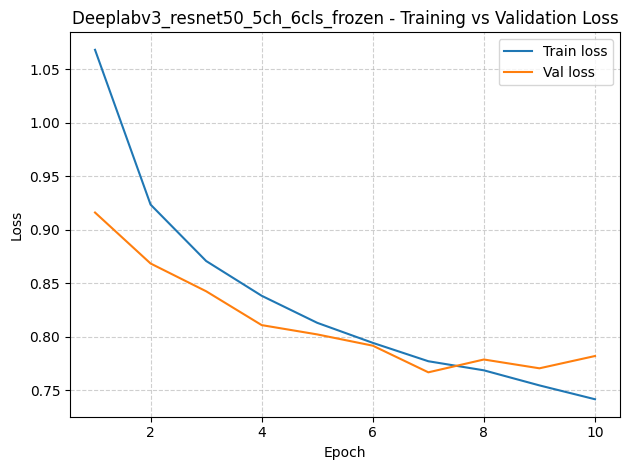

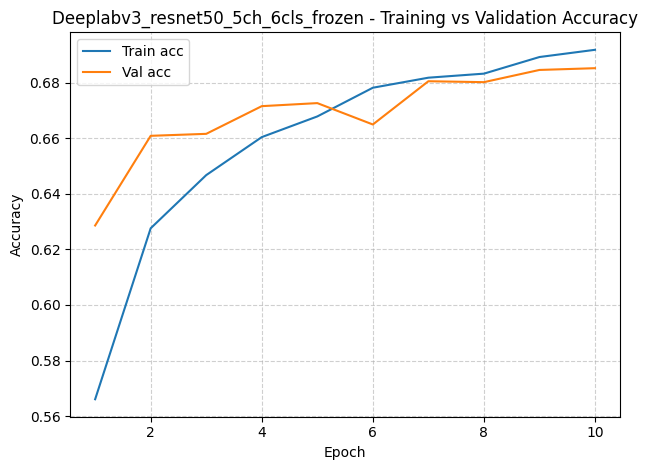

In [ ]:
general_plot_curves(dl_tr_loss, dl_tr_acc, dl_val_loss, dl_val_acc, model_name="Deeplabv3_resnet50_5ch_6cls_frozen")

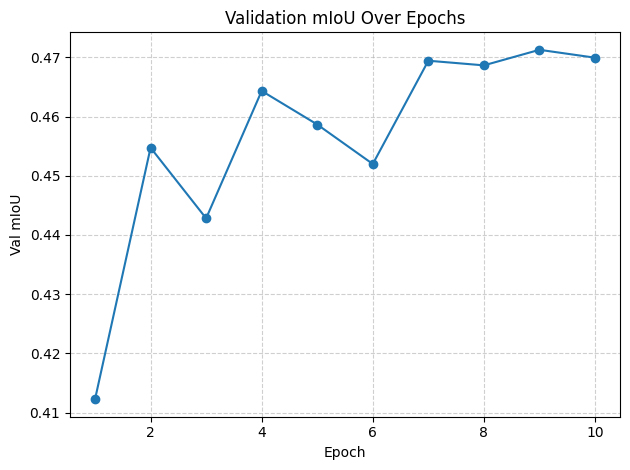

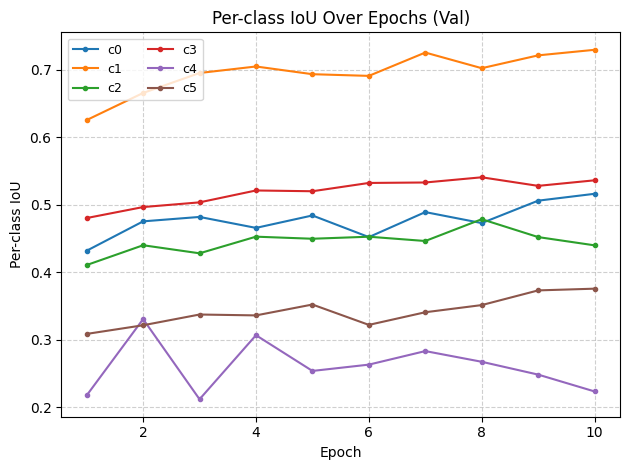

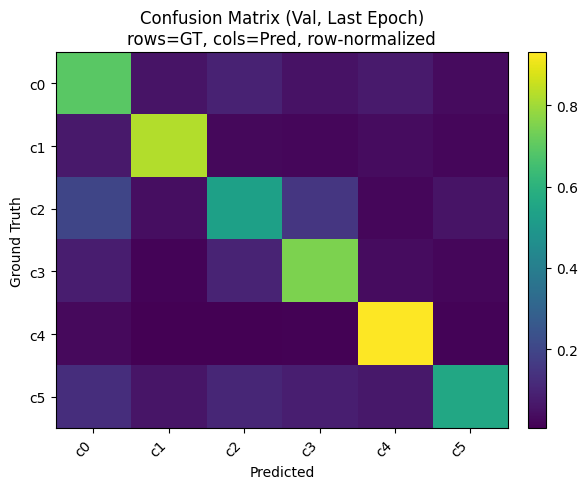

In [ ]:

plot_key_metrics(
    dl_val_miou,
    dl_per_class_hist,
    dl_cm_hist,
    class_names=None,        
    prefix=""  # controls filenames
)



In [ ]:
ckpt = torch.load("class_weights.ckpt", map_location="cpu")
class_weights = ckpt["class_weights"].to(device)



#class_weights = get_class_weights(train_loader, num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_finetune = torch.optim.Adam(
    deeplab.parameters(),
    lr=1e-5,  # Lower learning rate
    weight_decay=1e-5
)



In [21]:
torch.save(
    {
        "class_weights":class_weights

    },
    "./class_weights.ckpt",
)

# 4: segFormer frozen

In [ ]:
def build_segformer_5ch_6cls_frozen(model_name="nvidia/segformer-b0-finetuned-ade-512-512", 
                                     in_channels=5, 
                                     num_classes=6):

    # Build SegFormer with:
    # - 5 input channels (R, G, B, NIR, DSM)
    # - 6 output classes (Potsdam classes)
    # - Frozen encoder (backbone)
    
    
    # 1. Load pretrained model
    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name,
        num_labels=num_classes,  
        ignore_mismatched_sizes=True
    )
    
    # 2. Modify first patch embedding layer (3 -> 5 channels)
    old_patch_embed = model.segformer.encoder.patch_embeddings[0].proj
    
    new_patch_embed = nn.Conv2d(
        in_channels,
        old_patch_embed.out_channels,
        kernel_size=old_patch_embed.kernel_size,
        stride=old_patch_embed.stride,
        padding=old_patch_embed.padding
    )
    
    # 3. Initialize weights
    with torch.no_grad():
        new_patch_embed.weight[:, :3, :, :] = old_patch_embed.weight
        
        if in_channels > 3:
            mean_rgb = old_patch_embed.weight.mean(dim=1, keepdim=True)
            new_patch_embed.weight[:, 3:in_channels, :, :] = mean_rgb.repeat(1, in_channels-3, 1, 1)
    
    model.segformer.encoder.patch_embeddings[0].proj = new_patch_embed
    
    # 4. Freeze encoder
    for param in model.segformer.encoder.parameters():
        param.requires_grad = False
    
    # 5. Keep decoder trainable
    for param in model.decode_head.parameters():
        param.requires_grad = True
    
    # 6. Wrapper with upsampling
    class SegFormerFrozenEncoder(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        
        def train(self, mode: bool = True):
            super().train(mode)
            self.m.segformer.encoder.eval()
            return self
        
        def forward(self, x):
            outputs = self.m(pixel_values=x)
            logits = outputs.logits
            
            # Upsample to input size
            logits = F.interpolate(
                logits, 
                size=x.shape[-2:],
                mode='bilinear', 
                align_corners=False
            )
            return logits
    
    return SegFormerFrozenEncoder(model)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6
in_channels = 5

# Build SegFormer model
segTra = build_segformer_5ch_6cls_frozen(
    model_name="nvidia/segformer-b0-finetuned-ade-512-512",
    in_channels=in_channels, 
    num_classes=num_classes
)
segTra = segTra.to(device)

# Quick sanity check
print("Testing forward pass...")
segTra.eval()
with torch.no_grad():
    test_input = torch.randn(2, 5, 224, 224).to(device)
    test_output = segTra(test_input)
    print(f"Output shape: {test_output.shape}")

# Count parameters
trainable = sum(p.numel() for p in segTra.parameters() if p.requires_grad)
total = sum(p.numel() for p in segTra.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.1f}%)")


criterion = nn.CrossEntropyLoss(weight=class_weights)

head_params = [p for p in segTra.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(head_params, lr=1e-4, weight_decay=1e-5)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([6, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing forward pass...
Output shape: torch.Size([2, 6, 224, 224])
Trainable: 396,294 / Total: 3,718,822 (10.7%)


In [ ]:
# Train
segTra, seg_tr_loss, seg_tr_acc, seg_val_loss, seg_val_acc, seg_val_miou, seg_per_class_hist, seg_cm_hist = training_loop_with_iou_per_class(
    segTra, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=10, print_every=100, num_classes=num_classes
)
print("Val mIoU by epoch:", [round(x, 4) for x in seg_val_miou])

Starting training
	Batch 100/329: 	Train loss: 1.696, 	Train acc.: 0.280, 	Val. loss: 1.592, 	Val. acc.: 0.351, 	Val. mIoU: 0.181
	Val. per-class IoU: [0.198, 0.286, 0.231, 0.291, 0.059, 0.02]
	Batch 200/329: 	Train loss: 1.536, 	Train acc.: 0.402, 	Val. loss: 1.435, 	Val. acc.: 0.448, 	Val. mIoU: 0.244
	Val. per-class IoU: [0.243, 0.466, 0.29, 0.322, 0.087, 0.054]
	Batch 300/329: 	Train loss: 1.394, 	Train acc.: 0.466, 	Val. loss: 1.329, 	Val. acc.: 0.505, 	Val. mIoU: 0.277
	Val. per-class IoU: [0.303, 0.517, 0.329, 0.342, 0.122, 0.051]
Epoch 1/10: Train loss: 1.524, Train acc.: 0.392, Val. loss: 1.304, Val. acc.: 0.513, Val. mIoU: 0.285
Val per-class IoU: [0.309, 0.518, 0.338, 0.342, 0.129, 0.072]
	Batch 100/329: 	Train loss: 1.277, 	Train acc.: 0.513, 	Val. loss: 1.238, 	Val. acc.: 0.536, 	Val. mIoU: 0.305
	Val. per-class IoU: [0.357, 0.547, 0.337, 0.352, 0.153, 0.084]
	Batch 200/329: 	Train loss: 1.247, 	Train acc.: 0.539, 	Val. loss: 1.188, 	Val. acc.: 0.553, 	Val. mIoU: 0.324
	Va

In [53]:

# have to run
segTra, seg_tr_loss, seg_tr_acc, seg_val_loss, seg_val_acc, seg_val_miou, seg_per_class_hist, seg_cm_hist 
torch.save(
    {
        "model_state_dict": segTra.state_dict(),
        "train_losses": seg_tr_loss,
        "train_accs": seg_tr_acc,
        "val_losses": seg_val_loss,
        "val_accs": seg_val_acc,
        "val_miou": seg_val_miou,
        "val_per_class_history":seg_per_class_hist,
        "cm_history":seg_cm_hist

    },
    "./segformer_5ch_6cls_frozen.ckpt",
)



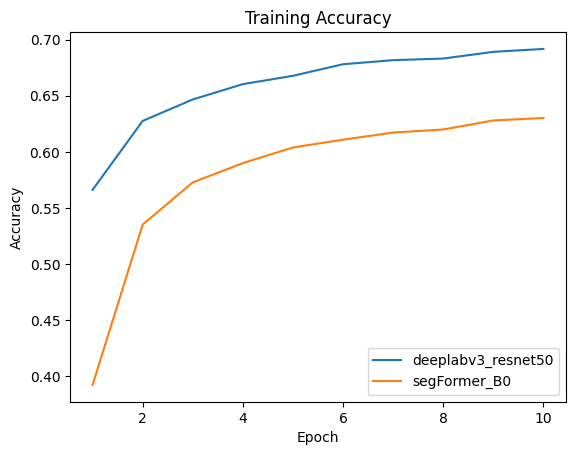

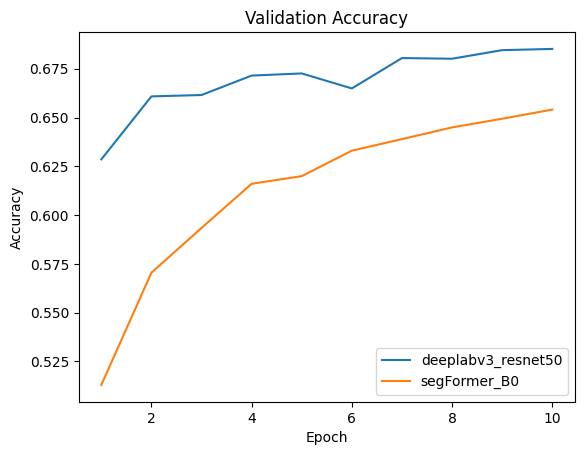

In [54]:
plot_compare_acc(dl_tr_acc, dl_val_acc,
                 seg_tr_acc, seg_val_acc,
                 first_name="deeplabv3_resnet50", second_name="segFormer_B0")

In [ ]:
ckpt = torch.load("first_with_weights.ckpt", map_location="cpu")
base_cm_hist = ckpt["cm_history"]
base_miou=ckpt["val_miou"]



ckpt = torch.load("own_model.ckpt", map_location="cpu")
own_cm_history = ckpt["cm_history"]
own_miou=ckpt["val_miou"]

In [ ]:
import pandas as pd
import numpy as np
import torch


def per_class_f1_from_cm(confusion_matrix, num_classes=6):
    """Calculate per-class F1-score from confusion matrix."""
    f1_scores = []
    
    for c in range(num_classes):
        tp = confusion_matrix[c, c].item()
        fp = confusion_matrix[:, c].sum().item() - tp
        fn = confusion_matrix[c, :].sum().item() - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0
        
        f1_scores.append(f1)
    
    macro_f1 = sum(f1_scores) / len(f1_scores)
    
    return f1_scores, macro_f1


def extract_f1_history(cm_history, num_classes=6):
    """Extract F1-scores from confusion matrix history."""
    f1_history = []
    macro_f1_history = []
    
    for cm in cm_history:
        per_class_f1, macro_f1 = per_class_f1_from_cm(cm, num_classes)
        f1_history.append(per_class_f1)
        macro_f1_history.append(macro_f1)
    
    return f1_history, macro_f1_history



num_classes = 6


w_f1_history, w_macro_f1_history = extract_f1_history(base_cm_hist, num_classes)           # Baseline
o_f1_history, o_macro_f1_history = extract_f1_history(own_cm_history, num_classes)         # Deeper own
dl_f1_history, dl_macro_f1_history = extract_f1_history(dl_cm_hist, num_classes)         # DeepLabV3
seg_f1_history, seg_macro_f1_history = extract_f1_history(seg_cm_hist, num_classes)      # SegFormer

print("F1-scores extracted from confusion matrices!")



w_avg_macro_f1 = np.mean(w_macro_f1_history[-3:])
o_avg_macro_f1 = np.mean(o_macro_f1_history[-3:])
dl_avg_macro_f1 = np.mean(dl_macro_f1_history[-3:])
seg_avg_macro_f1 = np.mean(seg_macro_f1_history[-3:])

w_avg_miou = np.mean(base_miou[-3:])
o_avg_miou = np.mean(own_miou[-3:])
dl_avg_miou = np.mean(dl_val_miou[-3:])
seg_avg_miou = np.mean(seg_val_miou[-3:])


data = {
    'Model': ['Baseline', 'Deep Model', 'DeepLabV3', 'SegFormer'],
    'F1': [w_avg_macro_f1, o_avg_macro_f1, dl_avg_macro_f1, seg_avg_macro_f1],
    'IoU': [w_avg_miou, o_avg_miou, dl_avg_miou, seg_avg_miou]
}

df = pd.DataFrame(data)
df['F1'] = df['F1'].map('{:.4f}'.format)
df['IoU'] = df['IoU'].map('{:.4f}'.format)

print("\n" + "="*50)
print("FINAL RESULTS (Average of Last 3 Epochs)")
print("="*50)
print(df.to_string(index=False))
print("="*50)

df.to_csv('final_results.csv', index=False)
print("\n Saved to 'final_results.csv'")

F1-scores extracted from confusion matrices!

FINAL RESULTS (Average of Last 3 Epochs)
     Model     F1    IoU
  Baseline 0.5268 0.3724
Deep Model 0.6010 0.4440
 DeepLabV3 0.6258 0.4700
 SegFormer 0.5845 0.4274

 Saved to 'final_results.csv'
